# Data Cleaning And Analysis:
# [RSNA 2023 Abdominal Trauma Detection](https://www.kaggle.com/competitions/rsna-2023-abdominal-trauma-detection)

> Detect and classify traumatic abdominal injuries

![](https://www.kaggle.com/competitions/52254/images/header)

## Downloading Dataset From Kaggle
**DataSet Link**: [rsna-2023-atd-base](https://www.kaggle.com/datasets/hundred3421/rsna-2023-atd-base)


**Dataset Description**:The dataset provided encompasses a subset of data derived from the RSNA 2023 Abdominal Trauma Detection dataset, focusing on images depicting abdominal regions and associated abnormalities. It comprises 14 distinct labels categorizing various injuries and conditions affecting the abdomen.

The labels are structured as follows:

* `Bowel_Healthy`: Denotes images depicting the healthy state of the bowel within the abdominal region.
* `Bowel_Injury`: Represents images indicating injuries or abnormalities present within the bowel.
* `Extravasation_Healthy`: Refers to images showcasing the normal condition of extravasation, typically concerning fluid or blood flow outside of blood vessels.
* `Extravasation_Injury`: Indicates images revealing abnormalities or injuries related to extravasation, such as leakage or excessive flow.
* `Kidney_Healthy`: Represents images depicting the healthy state of the kidneys within the abdominal cavity.
* `Kidney_Low`: Denotes images highlighting abnormalities or conditions characterized by reduced kidney function or anomalies.
* `Kidney_High`: Indicates images showcasing conditions related to heightened activity or abnormalities in the kidneys.
* `Liver_Healthy`: Represents images depicting the normal, healthy condition of the liver within the abdomen.
* `Liver_Low`: Denotes images illustrating conditions or injuries associated with reduced liver function or abnormalities.
* `Liver_High`: Indicates images revealing conditions characterized by heightened activity or anomalies within the liver.
* `Spleen_Healthy`: Refers to images portraying the spleen in its healthy state within the abdominal region.
* `Spleen_Low`: Denotes images indicating abnormalities or injuries leading to reduced spleen function or anomalies.
* `Spleen_High`: Represents images showcasing conditions characterized by heightened activity or anomalies within the spleen.

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Downloading dataset from kaggle
!kaggle datasets download -d hundred3421/rsna-2023-atd-base

100% 11.6G/11.6G [08:21<00:00, 26.1MB/s]
100% 11.6G/11.6G [08:21<00:00, 24.9MB/s]


In [ ]:
# Unzipping the dataset obtained from kaggle
!unzip rsna-2023-atd-base.zip

## Data Cleaning

In [ ]:
!kaggle datasets download -d jayantarsode/rsna-abdominal-trauma-subset/data -p /content/my_folder

400 - Bad Request - Invalid datasetVersionNumber value


In [ ]:
# Downloading the train.csv containing the image paths and labels
import gdown
train_dataframe_url = 'https://drive.google.com/uc?id=1nv9HUIf6mh1qDSl4qRVBGYmL0MbAVN36'
train_dataframe_output = 'train.csv'
gdown.download(train_dataframe_url , train_dataframe_output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1nv9HUIf6mh1qDSl4qRVBGYmL0MbAVN36
From (redirected): https://drive.google.com/uc?id=1nv9HUIf6mh1qDSl4qRVBGYmL0MbAVN36&confirm=t&uuid=6bc94ac4-d8ee-4ed2-b98d-ef512d1e0fc3
To: /content/train.csv
100%|██████████| 185M/185M [00:01<00:00, 95.6MB/s]


'train.csv'

### 1. Getting The Structure Of Dataset

In [ ]:
import os
def count_items_in_folder(path):
    """
    Count the number of items (files and folders) in a given folder.
    """
    num_items = 0
    try:
        for item in os.listdir(path):
            if os.path.isdir(os.path.join(path, item)):
                num_items += 1  # Increment for the folder itself
                num_items += count_items_in_folder(os.path.join(path, item))  # Recursively count items in subfolders
            else:
                num_items += 1  # Count the file
    except PermissionError:
        pass  # Skip folders where permission is denied
    return num_items

def traverse_folders(path, indent=''):
    """
    Traverse through folders and subfolders, counting the number of items.
    """
    num_items = count_items_in_folder(path)
    print(f"{indent}├── {os.path.basename(path)} ({num_items} items)")
    for item in os.listdir(path):
        full_path = os.path.join(path, item)
        if os.path.isdir(full_path):
            traverse_folders(full_path, indent + '│   ')  # Recursively traverse through subfolders

# Call the function to print the file structure
traverse_folders("/content/train_images")

## 2. Loading And Cleaning Dataset

In [ ]:
import pandas as pd
train_data = pd.read_csv("train.csv")
train_data.head()

,patient_id,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high,any_injury,series_id,image_path
0,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/kaggle/input/rsna-2023-abdominal-trauma-detec...
1,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/kaggle/input/rsna-2023-abdominal-trauma-detec...
2,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/kaggle/input/rsna-2023-abdominal-trauma-detec...
3,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/kaggle/input/rsna-2023-abdominal-trauma-detec...
4,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/kaggle/input/rsna-2023-abdominal-trauma-detec...


### 2.1 Getting the dataframe information

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500653 entries, 0 to 1500652
Data columns (total 17 columns):
 #   Column                 Non-Null Count    Dtype 
---  ------                 --------------    ----- 
 0   patient_id             1500653 non-null  int64 
 1   bowel_healthy          1500653 non-null  int64 
 2   bowel_injury           1500653 non-null  int64 
 3   extravasation_healthy  1500653 non-null  int64 
 4   extravasation_injury   1500653 non-null  int64 
 5   kidney_healthy         1500653 non-null  int64 
 6   kidney_low             1500653 non-null  int64 
 7   kidney_high            1500653 non-null  int64 
 8   liver_healthy          1500653 non-null  int64 
 9   liver_low              1500653 non-null  int64 
 10  liver_high             1500653 non-null  int64 
 11  spleen_healthy         1500653 non-null  int64 
 12  spleen_low             1500653 non-null  int64 
 13  spleen_high            1500653 non-null  int64 
 14  any_injury             1500653 non

### 2.2 Cleaning Data.

1. **Step 1**: Removing the unwanted columns we will select only columns containig only image_paths and labels.
2. **Step 2**: Changing the image paths to valid image paths to our current working directory.
3. **Step 3:** Removong all the invalid images as we are working with 2,15,496 images and subset and train.csv have 15,00,653 image.
4. **Step 4:** Filter patients with at least one abnormality.
5. **Step 5:** Importing this dataframe for future use for loading dataset using dataframe and folders.
6. **Step 6:** Working on hypothesis that either a patient can have kidney/liver/spleen abnormatilites can have only one abnormanlity at a time and thus can be cosidered as multiclass classification.

In [ ]:
!unzip /content/torch_helper_functions-20240229T153921Z-001.zip

Archive:  /content/torch_helper_functions-20240229T153921Z-001.zip
  inflating: torch_helper_functions/multilabel/data_cleaner.py  
  inflating: torch_helper_functions/utils.py  
  inflating: torch_helper_functions/multilabel/data_setup.py  
  inflating: torch_helper_functions/plotting_utils.py  
  inflating: torch_helper_functions/multilabel/train_engine.py  


In [ ]:
# Importing custom dataframe module from github
from torch_helper_functions.multilabel import data_cleaner
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Step 1:
selected_columns=['image_path',
                  'bowel_healthy', 'bowel_injury',
                  'extravasation_healthy','extravasation_injury',
                  'kidney_healthy', 'kidney_low', 'kidney_high',
                   'liver_healthy', 'liver_low', 'liver_high',
                  'spleen_healthy','spleen_low', 'spleen_high']
train_data = train_data[selected_columns]
train_data.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
0,/kaggle/input/rsna-2023-abdominal-trauma-detec...,1,0,0,1,0,1,0,1,0,0,0,0,1
1,/kaggle/input/rsna-2023-abdominal-trauma-detec...,1,0,0,1,0,1,0,1,0,0,0,0,1
2,/kaggle/input/rsna-2023-abdominal-trauma-detec...,1,0,0,1,0,1,0,1,0,0,0,0,1
3,/kaggle/input/rsna-2023-abdominal-trauma-detec...,1,0,0,1,0,1,0,1,0,0,0,0,1
4,/kaggle/input/rsna-2023-abdominal-trauma-detec...,1,0,0,1,0,1,0,1,0,0,0,0,1


In [ ]:
# Step 2:
print(f"Images are paths before preprocessing:{train_data['image_path'][0]}")
train_data=data_cleaner.preprocess_image_paths(df=train_data,
                                               image_path_column='image_path',
                                               orignal_path='/kaggle/input/rsna-2023-abdominal-trauma-detection/',
                                               new_path='/content/',
                                               old_extension='.dcm',
                                               new_extension='.png')
print(f"Images are paths after preprocessing:{train_data['image_path'][0]}")

Images are paths before preprocessing:/kaggle/input/rsna-2023-abdominal-trauma-detection/train_images/10004/21057/1000.dcm
Images are paths after preprocessing:/content/train_images/10004/21057/1000.png


In [ ]:
# Step 3:
print(f"Number of images before validations: {train_data.shape[0]}")
train_data=data_cleaner.validate_image_paths(df=train_data,
                                             image_path_column='image_path',
                                             folder_path='/content/train_images',
                                             save_path='root')
print(f"Number of images found existing after validations: {train_data.shape[0]}")

Number of images before validations: 1500653
Number of images found existing after validations: 150066


In [ ]:
# Step 4:
patients_with_abnormalities = train_data[(train_data['bowel_injury']==1) | (train_data['extravasation_injury']==1)|
                                        (train_data['kidney_low']==1) | (train_data['kidney_high']==1) |
                                        (train_data['liver_low']==1) | (train_data['liver_high']==1) |
                                        (train_data['spleen_low']==1) | (train_data['spleen_high']==1)].copy()
columns=['bowel_healthy', 'bowel_injury',
         'extravasation_healthy','extravasation_injury',
         'kidney_healthy', 'kidney_low', 'kidney_high',
         'liver_healthy', 'liver_low', 'liver_high',
         'spleen_healthy','spleen_low', 'spleen_high']
patients_with_abnormalities.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41486 entries, 603726 to 750294
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   image_path             41486 non-null  object
 1   bowel_healthy          41486 non-null  int64 
 2   bowel_injury           41486 non-null  int64 
 3   extravasation_healthy  41486 non-null  int64 
 4   extravasation_injury   41486 non-null  int64 
 5   kidney_healthy         41486 non-null  int64 
 6   kidney_low             41486 non-null  int64 
 7   kidney_high            41486 non-null  int64 
 8   liver_healthy          41486 non-null  int64 
 9   liver_low              41486 non-null  int64 
 10  liver_high             41486 non-null  int64 
 11  spleen_healthy         41486 non-null  int64 
 12  spleen_low             41486 non-null  int64 
 13  spleen_high            41486 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 4.7+ MB


In [ ]:
from sklearn.model_selection import train_test_split
# Getting paths that are not in train_data
filtered_train_data = train_data[~train_data['image_path'].isin(patients_with_abnormalities['image_path'])].copy()

# Getting split of data that we will add patients_with_abnormalities
_, data_to_add_df = train_test_split(filtered_train_data, test_size=0.4,random_state=42)

In [ ]:
patients_with_abnormalities = pd.concat([patients_with_abnormalities.copy(), data_to_add_df.copy()], axis=0)
patients_with_abnormalities.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84918 entries, 603726 to 681851
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   image_path             84918 non-null  object
 1   bowel_healthy          84918 non-null  int64 
 2   bowel_injury           84918 non-null  int64 
 3   extravasation_healthy  84918 non-null  int64 
 4   extravasation_injury   84918 non-null  int64 
 5   kidney_healthy         84918 non-null  int64 
 6   kidney_low             84918 non-null  int64 
 7   kidney_high            84918 non-null  int64 
 8   liver_healthy          84918 non-null  int64 
 9   liver_low              84918 non-null  int64 
 10  liver_high             84918 non-null  int64 
 11  spleen_healthy         84918 non-null  int64 
 12  spleen_low             84918 non-null  int64 
 13  spleen_high            84918 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 9.7+ MB


In [ ]:
def print_value_counts(df,label_columns):
  for i in label_columns:
    print(f"When {i.split('_')[0]} is {i.split('_')[1]} :\n")
    print(df[(df[i]==1)][label_columns].sum(),'\n')

In [ ]:
print_value_counts(patients_with_abnormalities,['kidney_healthy', 'kidney_low', 'kidney_high'])

When kidney is healthy :

kidney_healthy    73626
kidney_low            0
kidney_high           0
dtype: int64 

When kidney is low :

kidney_healthy       0
kidney_low        6616
kidney_high          0
dtype: int64 

When kidney is high :

kidney_healthy       0
kidney_low           0
kidney_high       4676
dtype: int64 



In [ ]:
print_value_counts(patients_with_abnormalities,['spleen_healthy','spleen_low', 'spleen_high'])

When spleen is healthy :

spleen_healthy    70408
spleen_low            0
spleen_high           0
dtype: int64 

When spleen is low :

spleen_healthy       0
spleen_low        9403
spleen_high          0
dtype: int64 

When spleen is high :

spleen_healthy       0
spleen_low           0
spleen_high       5107
dtype: int64 



In [ ]:
print_value_counts(patients_with_abnormalities,['liver_healthy', 'liver_low', 'liver_high'])

When liver is healthy :

liver_healthy    68169
liver_low            0
liver_high           0
dtype: int64 

When liver is low :

liver_healthy        0
liver_low        13129
liver_high           0
dtype: int64 

When liver is high :

liver_healthy       0
liver_low           0
liver_high       3620
dtype: int64 



In [ ]:
# Step 5:
train_data.to_csv("train_images_valid.csv")
patients_with_abnormalities.to_csv("patients_with_abnormalites.csv")

## Data Analysis

### 1. Downloading Valid Images DataFrame
- It contains valid image data and it's labels.

In [ ]:
# Downloading the patients_with_abnormalities.csv containing the image paths and labels
import gdown
train_dataframe_url = 'https://drive.google.com/uc?id=1-88s3vrBWicryPETDZQCI6RdgKHPk0g5'
train_dataframe_output = 'patients_with_abnormalities.csv'
gdown.download(train_dataframe_url , train_dataframe_output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-88s3vrBWicryPETDZQCI6RdgKHPk0g5
To: /content/patients_with_abnormalities.csv
100%|██████████| 6.33M/6.33M [00:00<00:00, 176MB/s]


'patients_with_abnormalities.csv'

### 2. Data Visualization And Inference

#### 2.1 One whole Training Data

In [ ]:
# Importing train_valid_images.csv
import pandas as pd
patients_with_abnormalities=pd.read_csv('/content/patients_with_abnormalities.csv').drop(columns=['Unnamed: 0'])
patients_with_abnormalities.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
0,/content/train_images/32982/5503/1000.png,1,0,1,0,1,0,0,1,0,0,0,1,0
1,/content/train_images/32982/5503/1001.png,1,0,1,0,1,0,0,1,0,0,0,1,0
2,/content/train_images/32982/5503/1002.png,1,0,1,0,1,0,0,1,0,0,0,1,0
3,/content/train_images/32982/5503/1003.png,1,0,1,0,1,0,0,1,0,0,0,1,0
4,/content/train_images/32982/5503/1004.png,1,0,1,0,1,0,0,1,0,0,0,1,0


🔑`Inference`: There are no null values in our dataframe.

In [ ]:
patients_with_abnormalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84918 entries, 0 to 84917
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   image_path             84918 non-null  object
 1   bowel_healthy          84918 non-null  int64 
 2   bowel_injury           84918 non-null  int64 
 3   extravasation_healthy  84918 non-null  int64 
 4   extravasation_injury   84918 non-null  int64 
 5   kidney_healthy         84918 non-null  int64 
 6   kidney_low             84918 non-null  int64 
 7   kidney_high            84918 non-null  int64 
 8   liver_healthy          84918 non-null  int64 
 9   liver_low              84918 non-null  int64 
 10  liver_high             84918 non-null  int64 
 11  spleen_healthy         84918 non-null  int64 
 12  spleen_low             84918 non-null  int64 
 13  spleen_high            84918 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 9.1+ MB


🔑`Inference`: From the description or summary of data we can infer that most labels are in form of 1 and 0 and not much to infer rather than this.

In [ ]:
patients_with_abnormalities.describe()

,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
count,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.000000,84918.00000,84918.000000
mean,0.987211,0.012789,0.869168,0.130832,0.867025,0.077910,0.055065,0.802763,0.154608,0.042629,0.829129,0.11073,0.060140
std,0.112363,0.112363,0.337219,0.337219,0.339550,0.268032,0.228108,0.397915,0.361533,0.202021,0.376398,0.31380,0.237748
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [ ]:
# Counts of each injury or healthy labels
columns=['bowel_healthy', 'bowel_injury',
         'extravasation_healthy','extravasation_injury',
         'kidney_healthy', 'kidney_low', 'kidney_high',
         'liver_healthy', 'liver_low', 'liver_high',
         'spleen_healthy','spleen_low', 'spleen_high']
counts = patients_with_abnormalities[columns].sum()
counts

bowel_healthy            83832
bowel_injury              1086
extravasation_healthy    73808
extravasation_injury     11110
kidney_healthy           73626
kidney_low                6616
kidney_high               4676
liver_healthy            68169
liver_low                13129
liver_high                3620
spleen_healthy           70408
spleen_low                9403
spleen_high               5107
dtype: int64

In [ ]:
def create_distribution_data_chart(df, columns):
    counts = df[columns].sum()
    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    plt.title('Distribution of Injury/Healthy in Abdominal Images')
    plt.show()

🔑`Inference`: From pie chart below we can conclude that:
* **Almost `(18.9%)` of the abdominal images show healthy bowels**. This is the largest single category.
* **The next largest category is spleen_healthy `(14.6%)`**. This suggests that the spleen is another relatively common organ to be imaged and found healthy.
* **There are several categories with very low percentages, including spleen_high `(0.4%)`, liver_high `(0.4%)`, and bowel_injury `(0.4%)`**. This suggests that these are relatively rare findings in abdominal images.

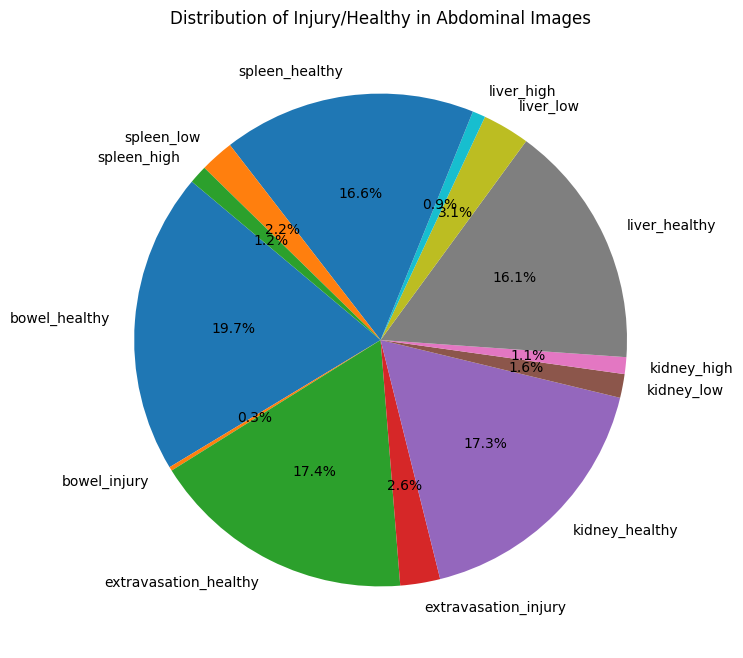

In [ ]:
import matplotlib.pyplot as plt
create_distribution_data_chart(df=patients_with_abnormalities,columns=columns)

**Purpose**: Cramér's V is a measure of association between two categorical variables. It quantifies the strength and direction of association beyond what would be expected by chance.

**Range**: Cramér's V ranges from 0 to 1, where 0 indicates no association between variables, and 1 indicates a perfect association. Intermediate values represent varying degrees of association.

**Formula**: Cramér's V is calculated using the chi-square statistic. It is defined as the square root of the chi-square statistic divided by the sample size and the minimum of the number of rows or columns minus 1.

**Interpretation**: The interpretation of Cramér's V is similar to that of Pearson's correlation coefficient. A value close to 0 suggests little to no association between variables, while values closer to 1 indicate a stronger association.

In [ ]:
# Creating a correlational matrix to find if there are any correlation between injuries
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np
# Function to compute Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

🔑`Inference`: From correlation matrix we can say that our data is valid as for example:
* **There is a strong  correlation `(1)` between bowel_healthy and bowel_injury**. This means that when bowel_healthy is high, bowel_injury is low, and vice versa. This suggests that a healthy bowel is less likely to be injured.

Thus we will not be using healthy labels to train our model as it creates correlation problem and consider bowel and extravasation injuries for binary classification.

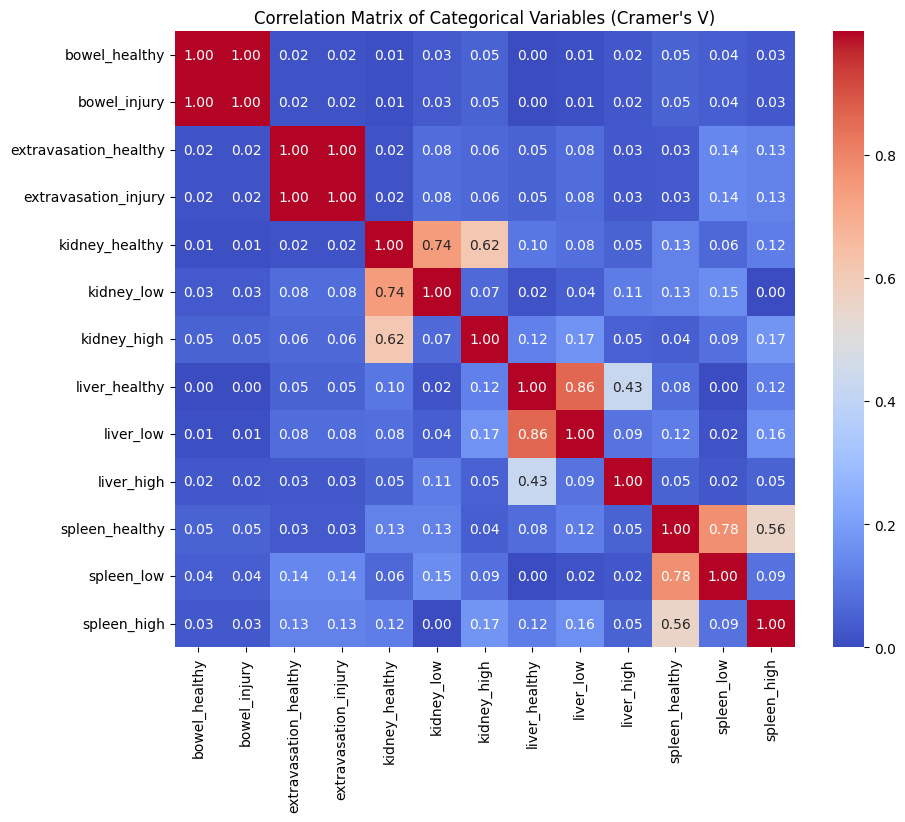

In [ ]:
# Compute the correlation matrix using Cramer's V
corr_matrix = pd.DataFrame(index=patients_with_abnormalities[columns].columns, columns=patients_with_abnormalities[columns].columns, dtype=float)
for i in range(len(patients_with_abnormalities[columns].columns)):
    for j in range(len(patients_with_abnormalities[columns].columns)):
        corr_matrix.iloc[i, j] = cramers_v(patients_with_abnormalities[columns].iloc[:, i], patients_with_abnormalities[columns].iloc[:, j])

# Plot the correlation matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Categorical Variables (Cramer\'s V)')
plt.show()

🔑`Inference`: From the below chi-square test we can say that there is:
* **quit a realtionship between all the injuries we can not say which type of realtionship but the realtionship are highly significant as we get from** `chi-square test`.

In [ ]:
# Conducting chi-square test to see if there are realtionship between injuries
import numpy as np
from scipy.stats import chi2_contingency
from typing import List
def chi_square_matrix_with_significance(df: pd.DataFrame, injury_columns: List[str]) -> pd.DataFrame:
    """
    Calculates a chi-square significance matrix for pairs of injury columns in a dataframe.

    Args:
        df (pd.DataFrame): Dataframe containing the injury columns.
        injury_columns (List[str]): List of injury column names.

    Returns:
        pd.DataFrame: A dataframe with significance levels for each pair of injuries.
    """

    significance_matrix = pd.DataFrame(index=injury_columns, columns=injury_columns, dtype=object)

    for i, organ1 in enumerate(injury_columns):
        for j, organ2 in enumerate(injury_columns):
            if i != j:
                contingency_table = pd.crosstab(df[organ1], df[organ2])

                if contingency_table.size > 0:
                    _, pval, _, _ = chi2_contingency(contingency_table)

                    if pval < 0.001:
                        significance = "Highly Significant"
                    elif pval < 0.05:
                        significance = "Significant"
                    else:
                        significance = "Non-Significant"

                    significance_matrix.iloc[i, j] = significance

    return significance_matrix


# Specify the injury columns
injury_columns = ["bowel_injury", "extravasation_injury", "kidney_low", "kidney_high",
                   "liver_low", "liver_high", "spleen_low", "spleen_high"]

# Calculate significance matrix
significance_matrix = chi_square_matrix_with_significance(patients_with_abnormalities, injury_columns)

# Print the significance matrix
print("Chi-Square Test Significance Matrix:")
significance_matrix

Chi-Square Test Significance Matrix:


,bowel_injury,extravasation_injury,kidney_low,kidney_high,liver_low,liver_high,spleen_low,spleen_high
bowel_injury,NaN,Highly Significant,Highly Significant,Highly Significant,Significant,Highly Significant,Highly Significant,Highly Significant
extravasation_injury,Highly Significant,NaN,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant
kidney_low,Highly Significant,Highly Significant,NaN,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Non-Significant
kidney_high,Highly Significant,Highly Significant,Highly Significant,NaN,Highly Significant,Highly Significant,Highly Significant,Highly Significant
liver_low,Significant,Highly Significant,Highly Significant,Highly Significant,NaN,Highly Significant,Highly Significant,Highly Significant
liver_high,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant,NaN,Highly Significant,Highly Significant
spleen_low,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant,NaN,Highly Significant
spleen_high,Highly Significant,Highly Significant,Non-Significant,Highly Significant,Highly Significant,Highly Significant,Highly Significant,NaN


🔑 `Creating Our Own Dataset On Kaggle`
> 1. **Step1**: Copying all selected files from orignal dataset to our folder.
> 2. **Step 2**: Uploading dataset on kaggle.

In [ ]:
import pandas as pd
import os
import shutil

orignal_folder = '/content/train_images'  # Source folder containing all images
new_folder = '/content/ADT_train_images'  # Destination folder to move selected images

# Ensure the destination folder exists
if not os.path.exists(new_folder):
    os.makedirs(new_folder)

df = patients_with_abnormalities.copy()
# Loop through each file path in the DataFrame
for index, row in df.iterrows():
    file_path = row['image_path']
    # Extract the directory path and the filename from the file path
    directory, filename = os.path.split(file_path)
    # Create the new directory structure inside the new folder
    new_directory = os.path.join(new_folder, directory.split('/')[-2], directory.split('/')[-1])
    os.makedirs(new_directory, exist_ok=True)
    # Construct the new file path
    new_file_path = os.path.join(new_directory, filename)
    # Move the file to the new location
    shutil.move(file_path, new_file_path)

In [ ]:
!chmod 644 /content/rsna_atd_subset/dataset-metadata.json

In [ ]:
!kaggle datasets init -p /content/rsna_atd_subset

In [ ]:
!kaggle datasets create -p /content/rsna_atd_subset --dir-mode tar

#### 2.1 One Training,Validation And Testing Data
* Here we will be spliting the training,testing and validation and testing data we will be going to while training our model latter and check data distribution.
* Data Distribution:
  * `Train Data` : 61353 images.
  * `Validation Data` : 10827 images.
  * `Test Data` : 10416 images

In [ ]:
from sklearn.model_selection import train_test_split
# Split the DataFrame into train and test data
train_data, test_data = train_test_split(patients_with_abnormalities, test_size=0.15,random_state=42)

# Further split the train data into train and validation data
train_data, val_data = train_test_split(train_data, test_size=0.15, random_state=42)
print(f"Train Data contains: {len(train_data)}")
print(f"Validation Data contains: {len(val_data)}")
print(f"Test Data contains: {len(test_data)}")

Train Data contains: 61353
Validation Data contains: 10827
Test Data contains: 12738


🔑 `Train Data`

In [ ]:
# Counts of each injury or healthy labels
columns=['bowel_healthy', 'bowel_injury',
         'extravasation_healthy','extravasation_injury',
         'kidney_healthy', 'kidney_low', 'kidney_high',
         'liver_healthy', 'liver_low', 'liver_high',
         'spleen_healthy','spleen_low', 'spleen_high']
counts = train_data[columns].sum()
counts

bowel_healthy            60586
bowel_injury               767
extravasation_healthy    53250
extravasation_injury      8103
kidney_healthy           53148
kidney_low                4812
kidney_high               3393
liver_healthy            49297
liver_low                 9432
liver_high                2624
spleen_healthy           50864
spleen_low                6775
spleen_high               3714
dtype: int64

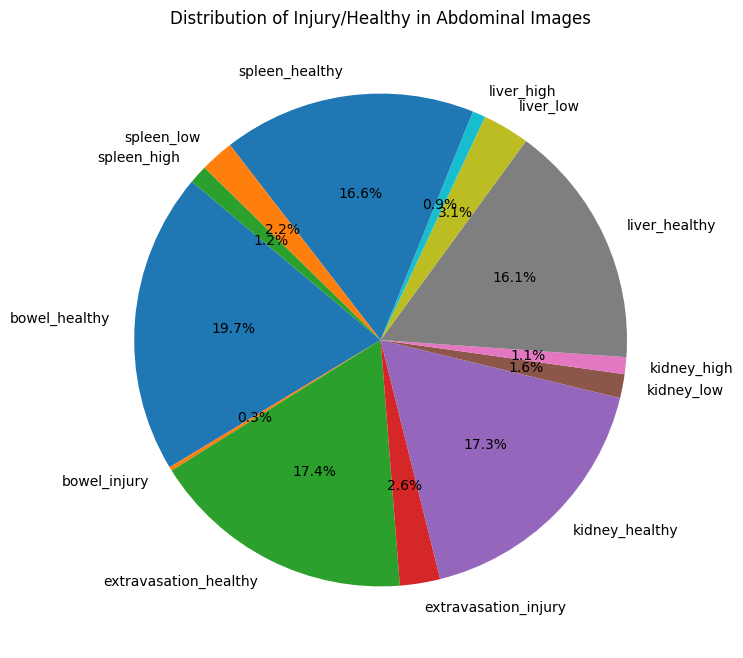

In [ ]:
# Checking the distribution of injuries/healthy in train_data
create_distribution_data_chart(df=train_data,columns=columns)

🔑 `Validation Data`

In [ ]:
# Counts of each injury or healthy labels
counts = val_data[columns].sum()
counts

bowel_healthy            10675
bowel_injury               152
extravasation_healthy     9444
extravasation_injury      1383
kidney_healthy            9390
kidney_low                 820
kidney_high                617
liver_healthy             8686
liver_low                 1694
liver_high                 447
spleen_healthy            8994
spleen_low                1203
spleen_high                630
dtype: int64

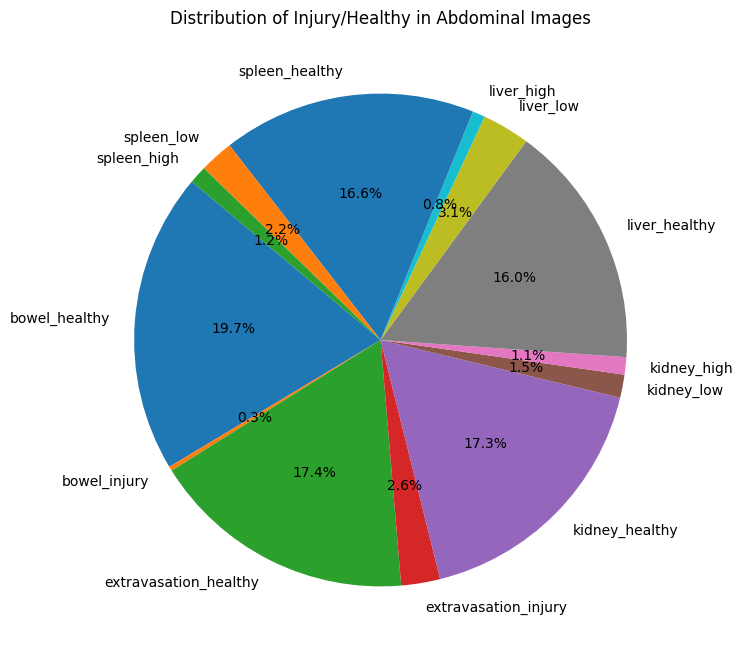

In [ ]:
create_distribution_data_chart(df=val_data,columns=columns)

🔑 `Test Data`

In [ ]:
# Counts of each injury or healthy labels
counts = test_data[columns].sum()
counts

bowel_healthy            12571
bowel_injury               167
extravasation_healthy    11114
extravasation_injury      1624
kidney_healthy           11088
kidney_low                 984
kidney_high                666
liver_healthy            10186
liver_low                 2003
liver_high                 549
spleen_healthy           10550
spleen_low                1425
spleen_high                763
dtype: int64

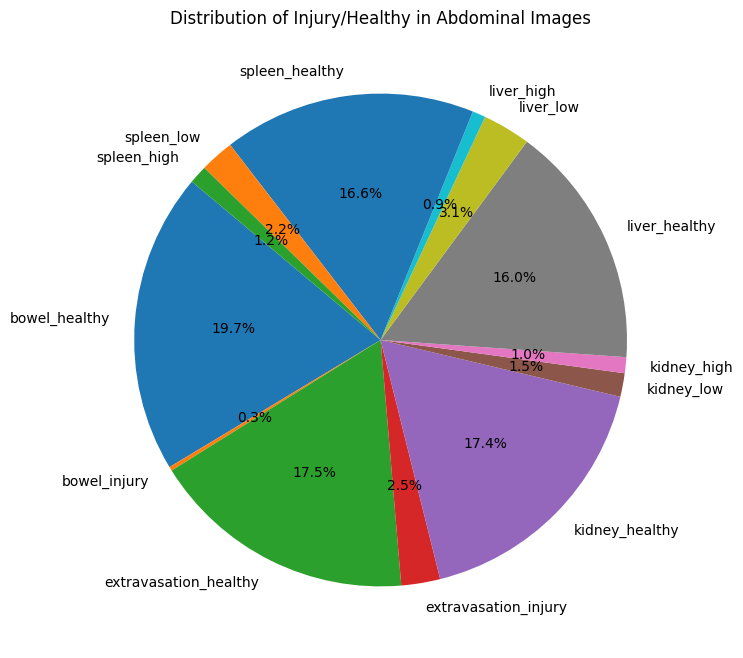

In [ ]:
# Checking the distribution of injuries/healthy in train_data
create_distribution_data_chart(df=test_data,columns=columns)

In [ ]:
test_data['image_path'].str.split('/').str[-3].unique()

array(['35574', '35908', '35997', '34965', '37436', '3747', '3399',
       '37119', '35372', '3295', '33007', '34401', '38045', '35449',
       '33100', '37789', '37459', '34838', '37276', '37123', '3411',
       '37164', '35941', '36576', '34098', '3414', '33891', '37637',
       '37429', '34200', '38001', '38337', '35187', '3475', '38150',
       '35863', '34522', '35168', '34366', '37942', '33845', '37273',
       '37022', '36940', '3749', '35653', '33967', '38238', '38343',
       '36695', '37551', '36277', '37820', '34091', '37748', '35058',
       '35659', '36859', '33219', '33848', '35842', '36963', '34354',
       '37169', '33485', '35765', '37101', '34204', '38129', '36356',
       '3401', '36982', '38123', '35489', '37009', '37338', '3575',
       '35056', '38003', '3373', '3506', '34943', '35072', '36017',
       '3342', '35473', '38088', '38194', '35185', '36105', '38200',
       '33330', '35444', '35821', '3568', '35447', '34952', '32943',
       '33111', '34864', '3652', 

In [ ]:
train_data['image_path'].str.split('/').str[-3].unique()

array(['33891', '37942', '36940', '3295', '35232', '34450', '33823',
       '37062', '3580', '38021', '34089', '37489', '37119', '36984',
       '38088', '37028', '34965', '36277', '35821', '35187', '37568',
       '33251', '38336', '3471', '34958', '32943', '33632', '3749',
       '33007', '3475', '3373', '36364', '37022', '37169', '384', '38056',
       '34190', '33219', '35863', '35580', '38238', '38129', '35168',
       '36686', '34869', '38386', '37637', '35839', '34469', '38337',
       '35941', '34140', '38003', '37338', '35842', '36576', '33811',
       '38067', '34952', '34386', '37597', '34717', '35185', '36944',
       '33501', '37694', '3308', '35372', '34943', '36091', '34785',
       '36285', '34838', '35331', '32982', '3717', '33578', '3401',
       '33475', '35138', '33648', '33130', '34091', '33', '37563',
       '37164', '36327', '35288', '33372', '37009', '34512', '36456',
       '35723', '35885', '3802', '3506', '37789', '35195', '33964',
       '38150', '35714', '3